In [2]:
import pandas as pd 

from ufc_betting.BettingStrategy.Backtest.backtest_functions import simulate_kelly
from ufc_betting.BettingStrategy.Backtest.backtest_plots import plot_backtest

In [ ]:
# https://vegapit.com/article/numerically_solve_kelly_criterion_multiple_simultaneous_bets/
# https://nickyoder.com/kelly-criterion/
# https://www.mma-ai.net/ 

# https://business.columbia.edu/sites/default/files-efs/pubfiles/6343/bayes_kelly.pdf
## Portfolio Choice and the Bayesian Kelly Criterion


In [3]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_test_open['date'].tail()


622    2026-02-21
623    2026-02-21
624    2026-02-21
625    2026-02-21
626    2026-02-21
Name: date, dtype: str

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


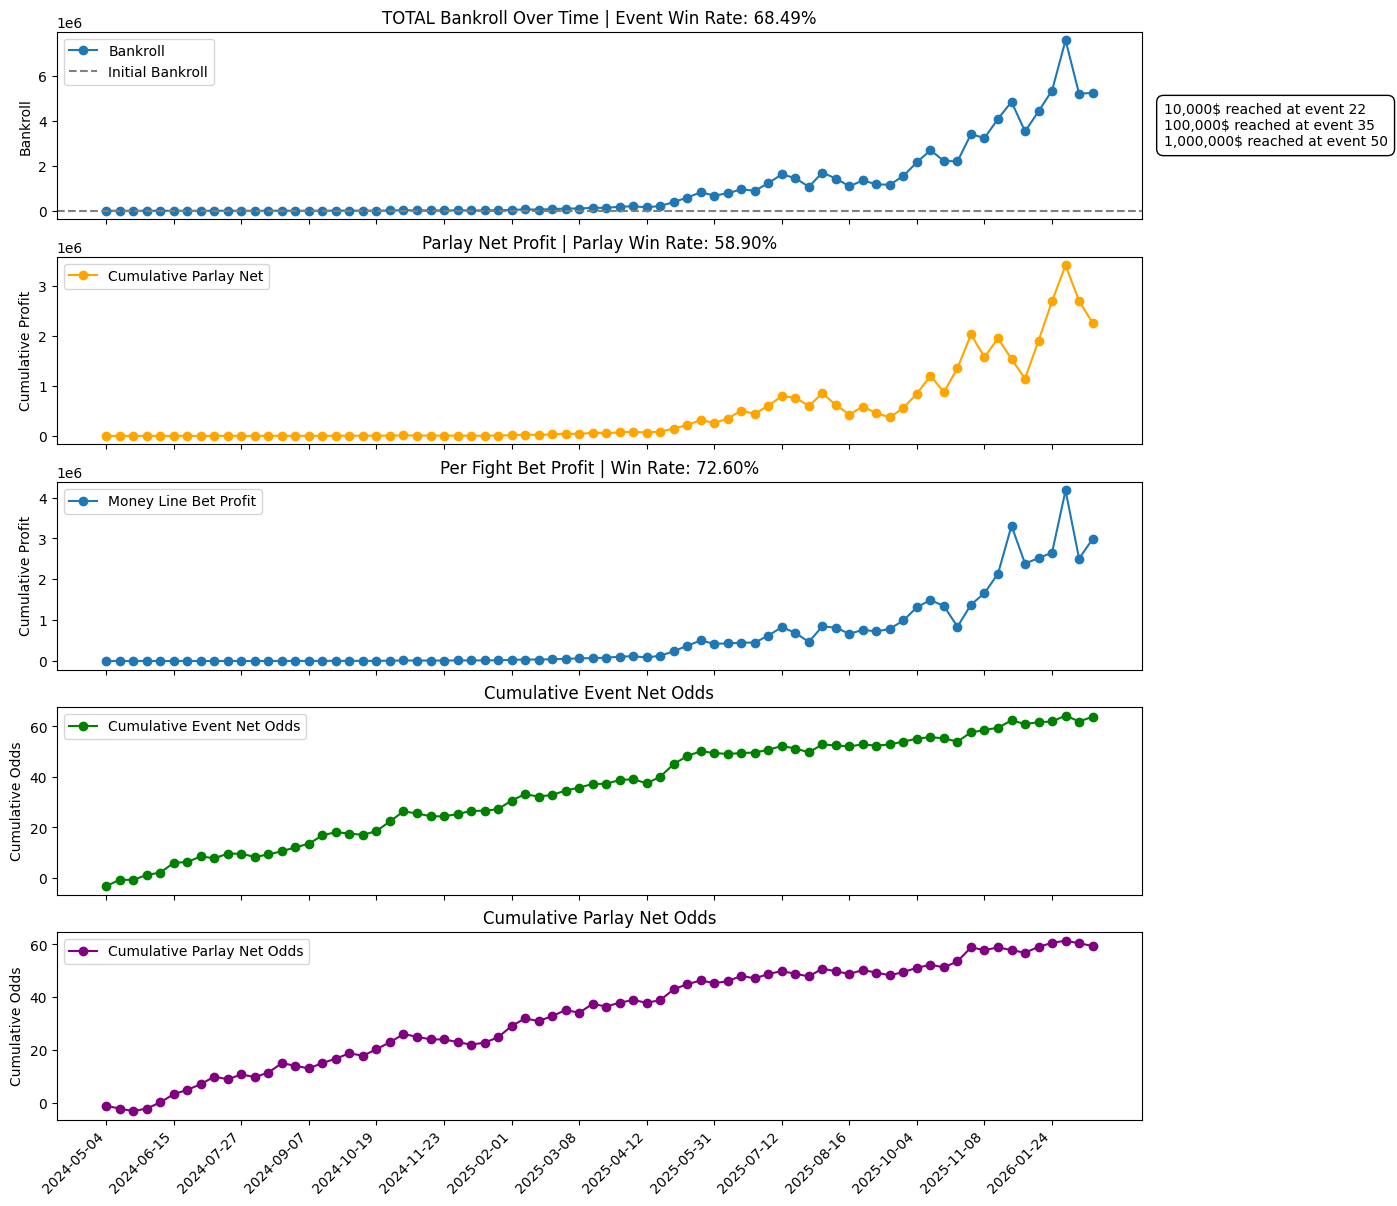

In [4]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']  # your decimal odds columns
real_decimal_odds = ['dec_open_blue', 'dec_open_red']

df_kelly, df_parlay,  = simulate_kelly(
    df_test_open,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,  
    max_drawdown=.3,
    parlay_mdd=.5,
    N=250,
    N_parlay=500,
    calc_parlay=True,
    test_other_ev=False
)

# plot_bankroll_distributions(df_kelly, df_parlay)
plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\open_kelly_sim.png'
plot_backtest(df_kelly, 500, path=plot_fp)
# plot_event_odds_stats(df_kelly)

# x_vars = ['mu_portfolio', 'sharpe_portfolio', 'portfolio_sigma']
# y_var = 'event_net_odds'
# kelly_analysis(df_kelly, x_vars, y_var)

df_kelly.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_open.csv')

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.

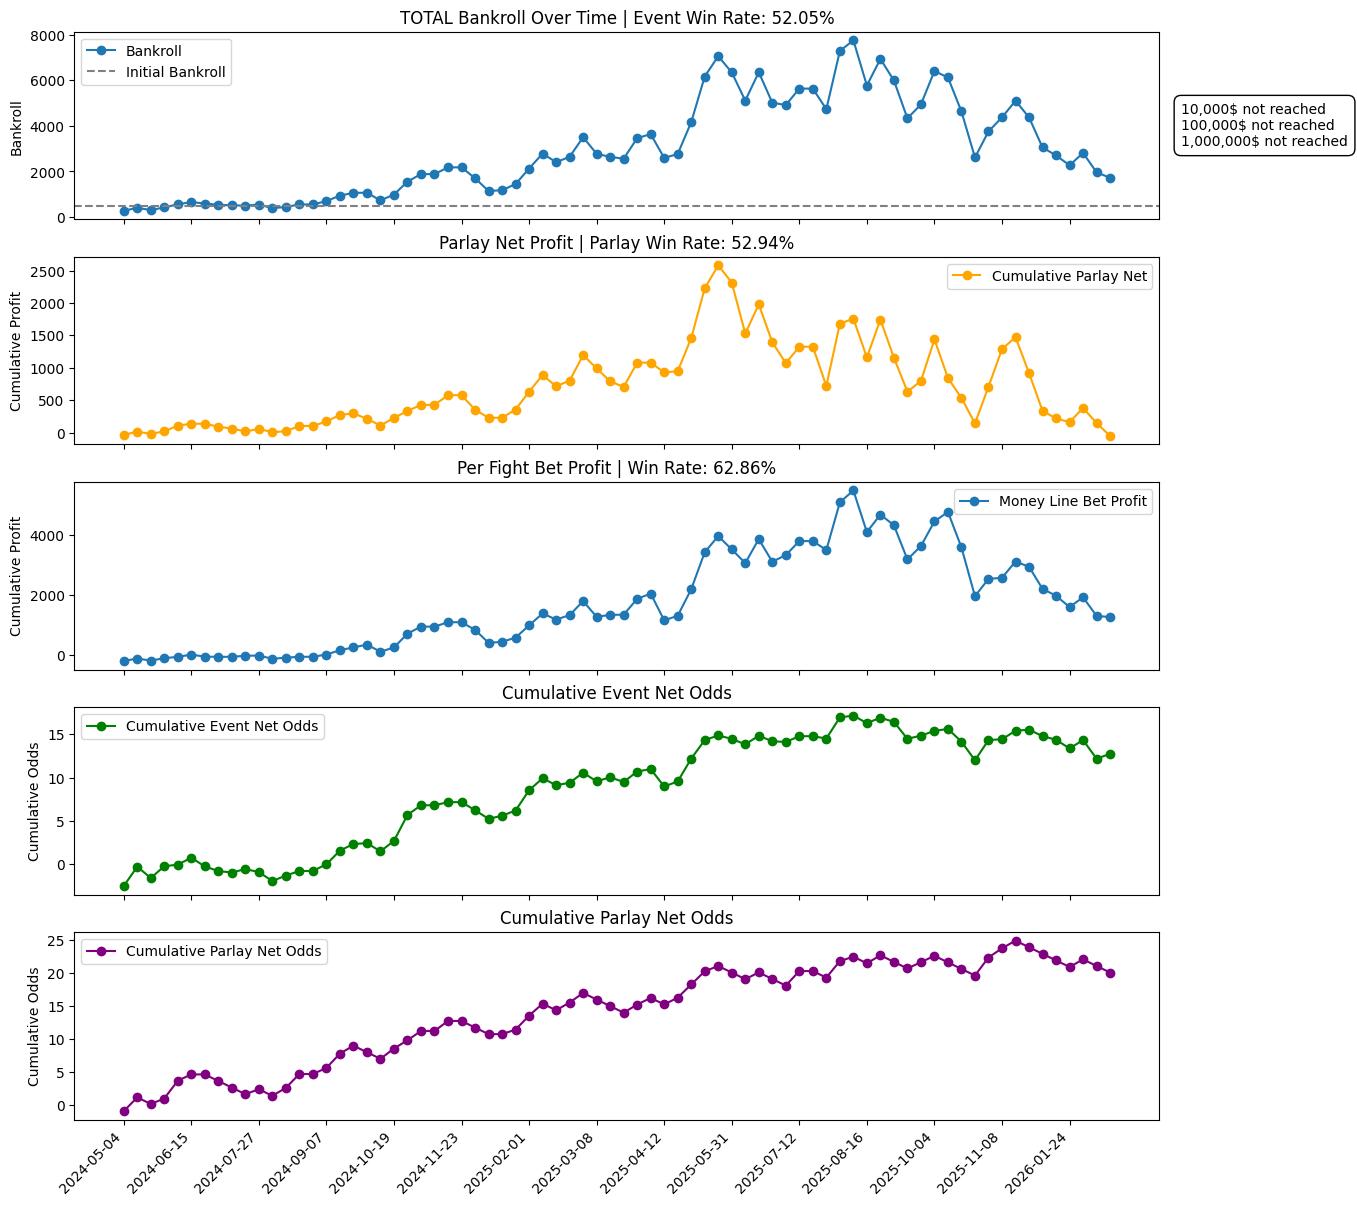

In [5]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']

df_kelly1, df_kelly1_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close1_kelly_sim.png'
plot_backtest(df_kelly1, 500, path=plot_fp)

df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
df_kelly1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close1.csv')

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


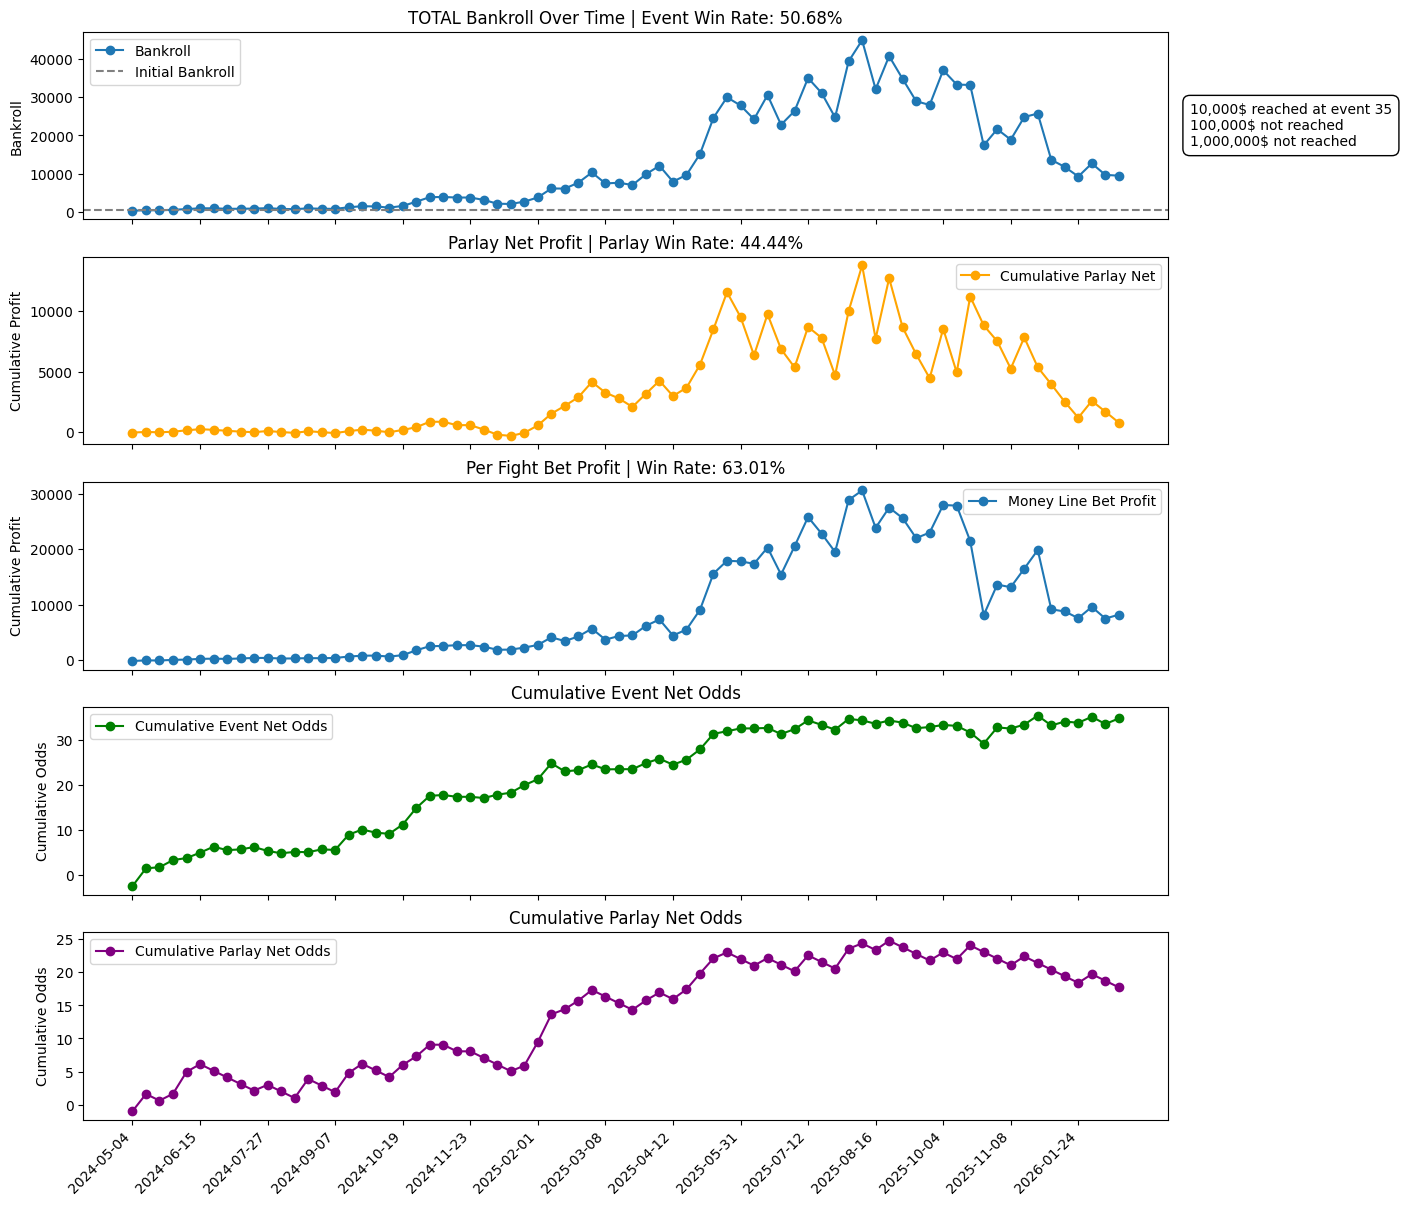

In [6]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')


prob_cols = ['proba_blue', 'proba_red']
# fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']
fair_decimal_odds = ['dec_fair_close2_blue', 'dec_fair_close2_red']  # your decimal odds columns
real_decimal_odds = ['dec_close2_blue', 'dec_close2_red']
df_kelly2, df_kelly2_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close2_kelly_sim.png'
plot_backtest(df_kelly2, 500, path=plot_fp)

df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close2.csv')
df_kelly2_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_close2.csv')

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


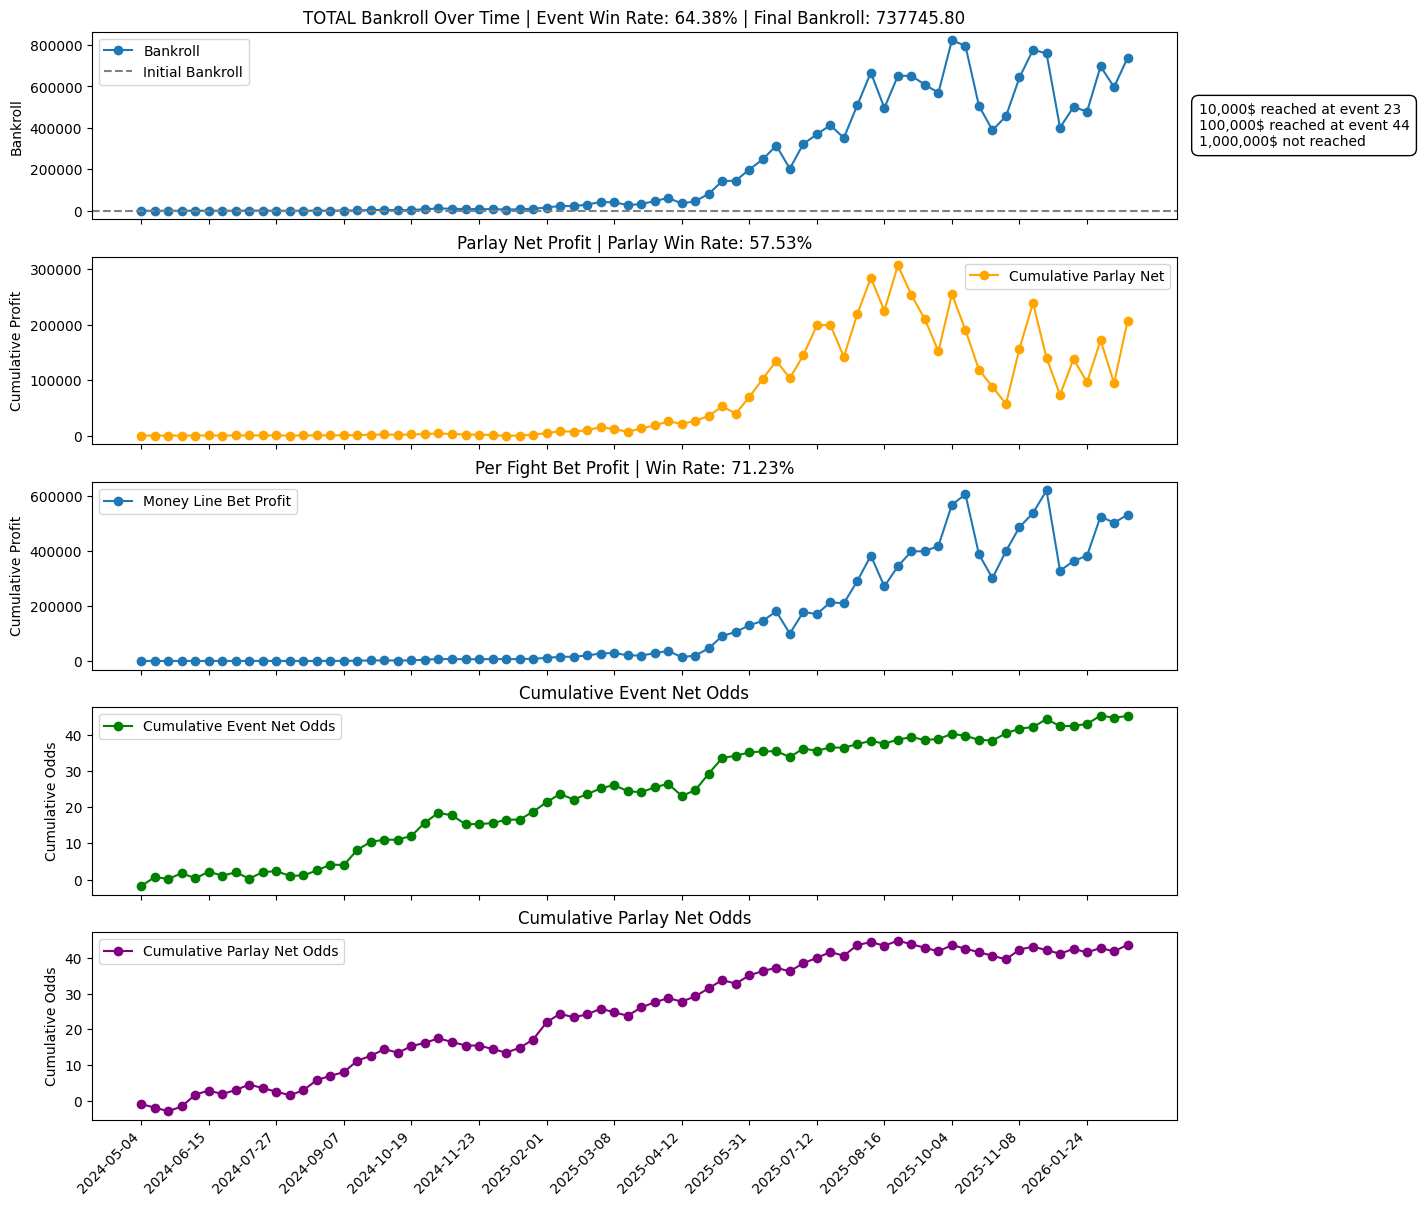

In [6]:
df_test_stack = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close2.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close2_blue', 'dec_fair_close2_red']  # your decimal odds columns
real_decimal_odds = ['dec_close2_blue', 'dec_close2_red']

df_kelly_stack2, df_kelly_stack2_parlay = simulate_kelly(
    df_test_stack,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    N_parlay=1000,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\stacking_kelly_sim.png'
plot_backtest(df_kelly_stack2, 500, path=plot_fp)

df_kelly_stack2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking.csv')
df_kelly_stack2_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_stacking.csv')

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


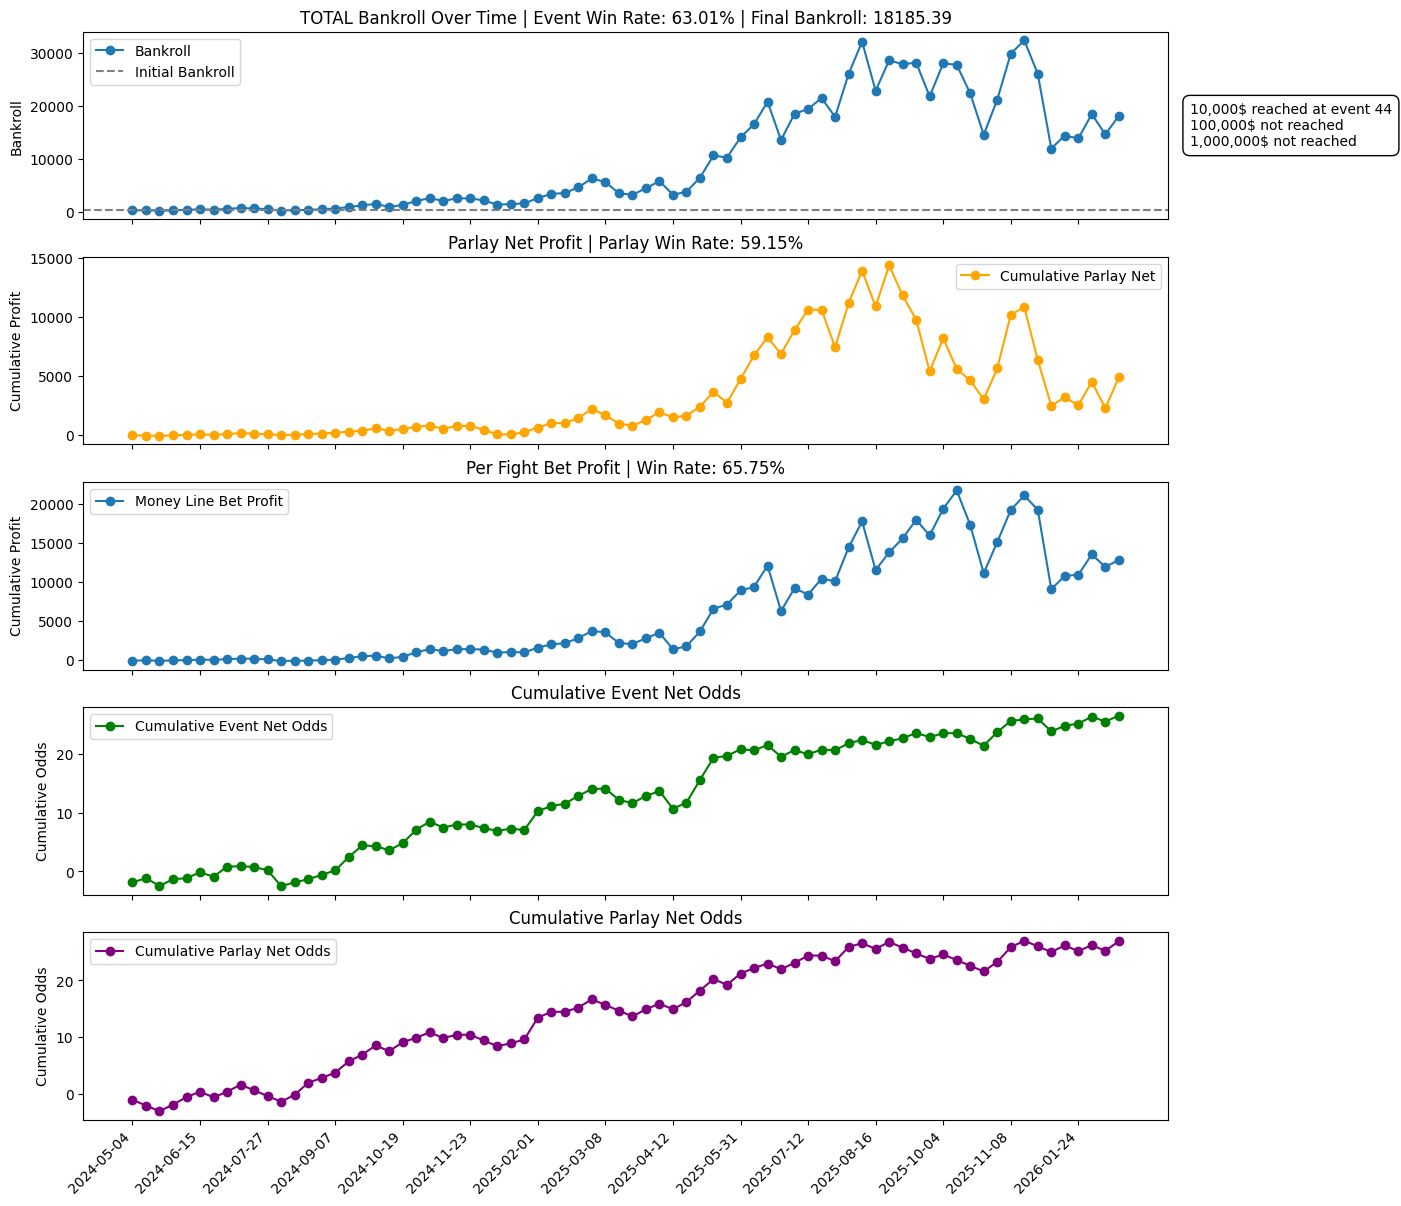

In [7]:
df_test_stack = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close1.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']

df_kelly_stack1, df_kelly_stack1_parlay = simulate_kelly(
    df_test_stack,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    N_parlay=1000,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\stacking_kelly_sim1.png'
plot_backtest(df_kelly_stack1, 500, path=plot_fp)

df_kelly_stack1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking1.csv')
df_kelly_stack1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_stacking1.csv')

In [1]:
from ufc_betting.VigStrategy.vig_functions import devig_two_way
from ufc_betting.BettingStrategy.Backtest.backtest_functions import simulate_kelly
from ufc_betting.BettingStrategy.Backtest.backtest_plots import plot_backtest

import numpy as np 
import pandas as pd 

df_test_all = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\Data\betting_results\moneyline_results.csv')
def american_to_decimal(odds):
    return np.where(odds > 0, odds / 100 + 1, 100 / np.abs(odds) + 1)

odds_types = ['open', 'close1', 'close2']
colors = ['red', 'blue']
rows = []
for type_ in odds_types: 
    df_test_all[f'{type_}_red'] = pd.to_numeric(df_test_all[f'{type_}_red'], errors='coerce')
    df_test_all[f'{type_}_blue'] = pd.to_numeric(df_test_all[f'{type_}_blue'], errors='coerce')


df_test_all = df_test_all.dropna(subset=[
    f'{type_}_{color}' for type_ in odds_types for color in colors
])


for _, row in df_test_all.iterrows(): 
    new_row = {}
    for type_ in odds_types: 
        dec_red = american_to_decimal(row[f'{type_}_red'])
        dec_blue = american_to_decimal(row[f'{type_}_blue'])
        pf_red, pf_blue, dec_fair_red, dec_fair_blue = devig_two_way(dec_red, dec_blue, method='power')
        new_row.update({
            f'dec_fair_{type_}_red':dec_fair_red,
            f'dec_fair_{type_}_blue':dec_fair_blue, 
            f'dec_{type_}_red':dec_red,
            f'dec_{type_}_blue':dec_blue
        })
    rows.append(new_row)

decs = pd.DataFrame(rows)

df_test_all = pd.concat([
    df_test_all.reset_index(drop=True),
    decs
], axis=1)
df_test_all = df_test_all.rename(columns={'winner_bool':'winner'})

In [2]:
prediction_types = [
    "open",
    "close1",
    "close2",
    "close1_stack",
    "close2_stack",
]

for type_ in prediction_types:
    prediction = pd.to_numeric(
        df_test_all[f"pred_winner_{type_}"],
        errors="coerce",
    )
    choice_proba = pd.to_numeric(
        df_test_all[f"choice_proba_{type_}"],
        errors="coerce",
    )
    valid_prediction = prediction.isin([0, 1])

    proba_red = choice_proba.where(
        prediction.eq(1),
        1 - choice_proba,
    ).where(valid_prediction)

    df_test_all[f"proba_red_{type_}"] = proba_red
    df_test_all[f"proba_blue_{type_}"] = (
        1 - proba_red
    )

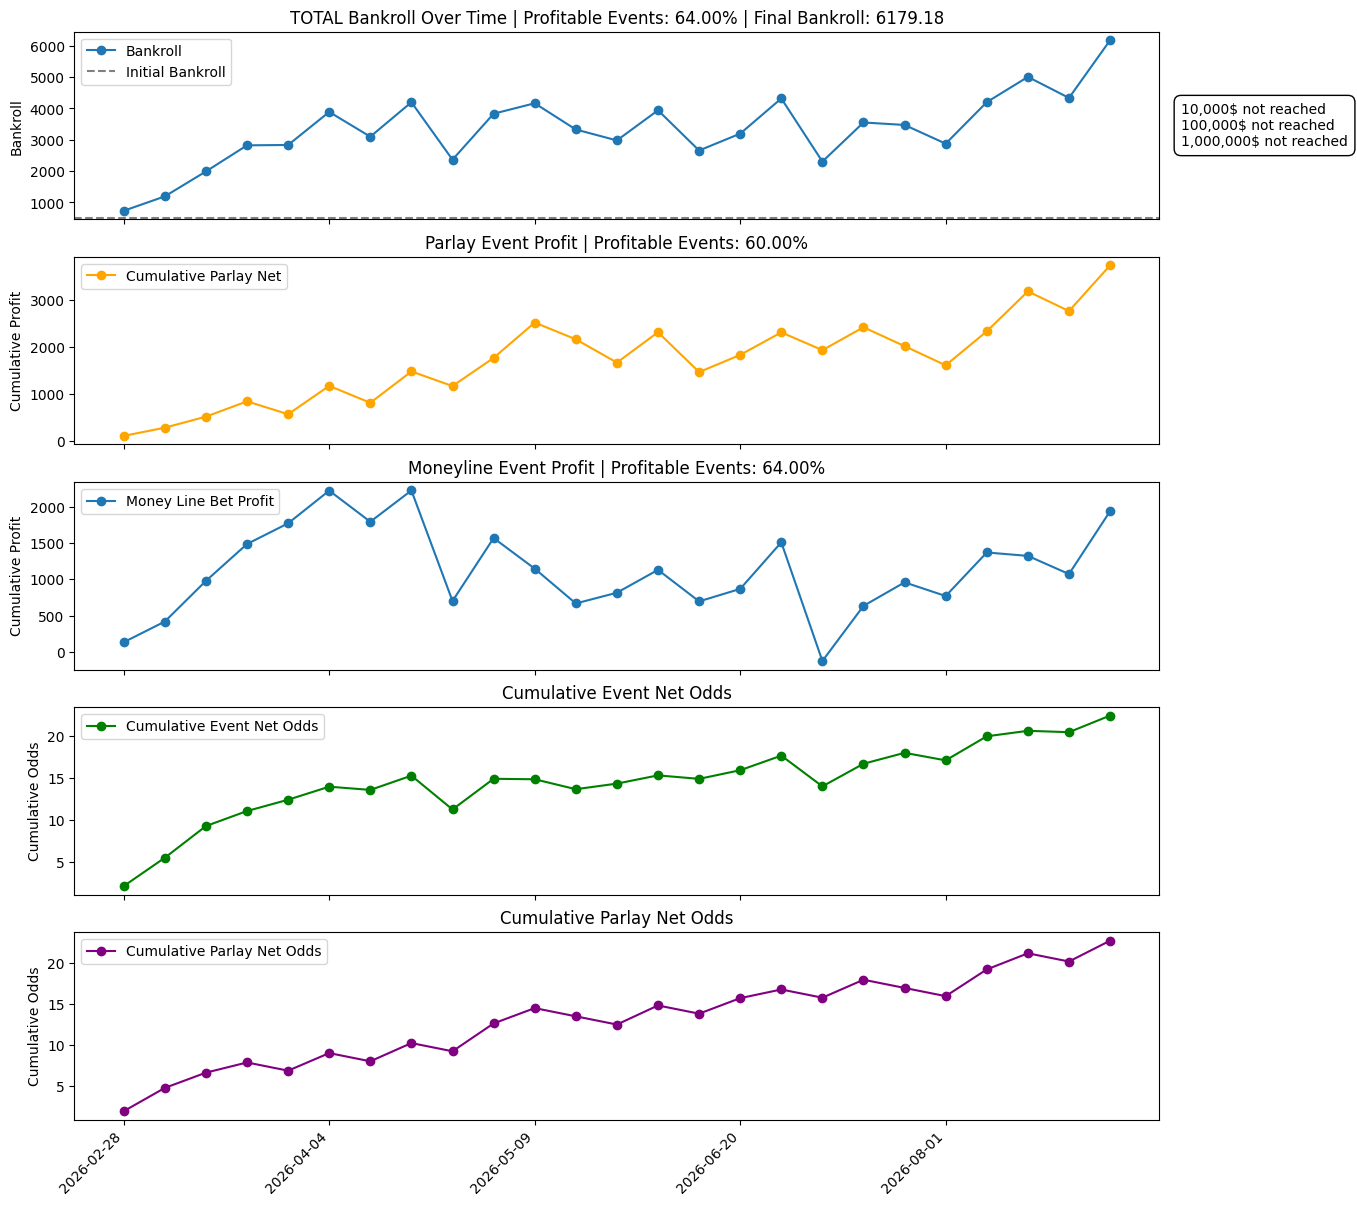

In [3]:
prob_cols = ['proba_blue_open', 'proba_red_open']
fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red'] 
real_decimal_odds = ['dec_open_blue', 'dec_open_red']
fight_key = ["date", "fighter_red", "fighter_blue"]

df_test_all = (
    df_test_all
    .drop_duplicates(subset=fight_key)
    .reset_index(drop=True)
)

df_kelly_stack1, df_kelly_stack1_parlay = simulate_kelly(
    df_test_all.dropna(subset=['pred_winner_open']).copy(),
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner_open',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.3,
    parlay_mdd=.5,
    N=250,
    N_parlay=500,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)


plot_backtest(df_kelly_stack1, 500, path=None)

# df_kelly_stack1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_stacking1.csv')
# df_kelly_stack1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\parlay_stacking1.csv')

Bankroll low on 2026-04-25, replenishing funds
Bankroll low on 2026-07-11, replenishing funds


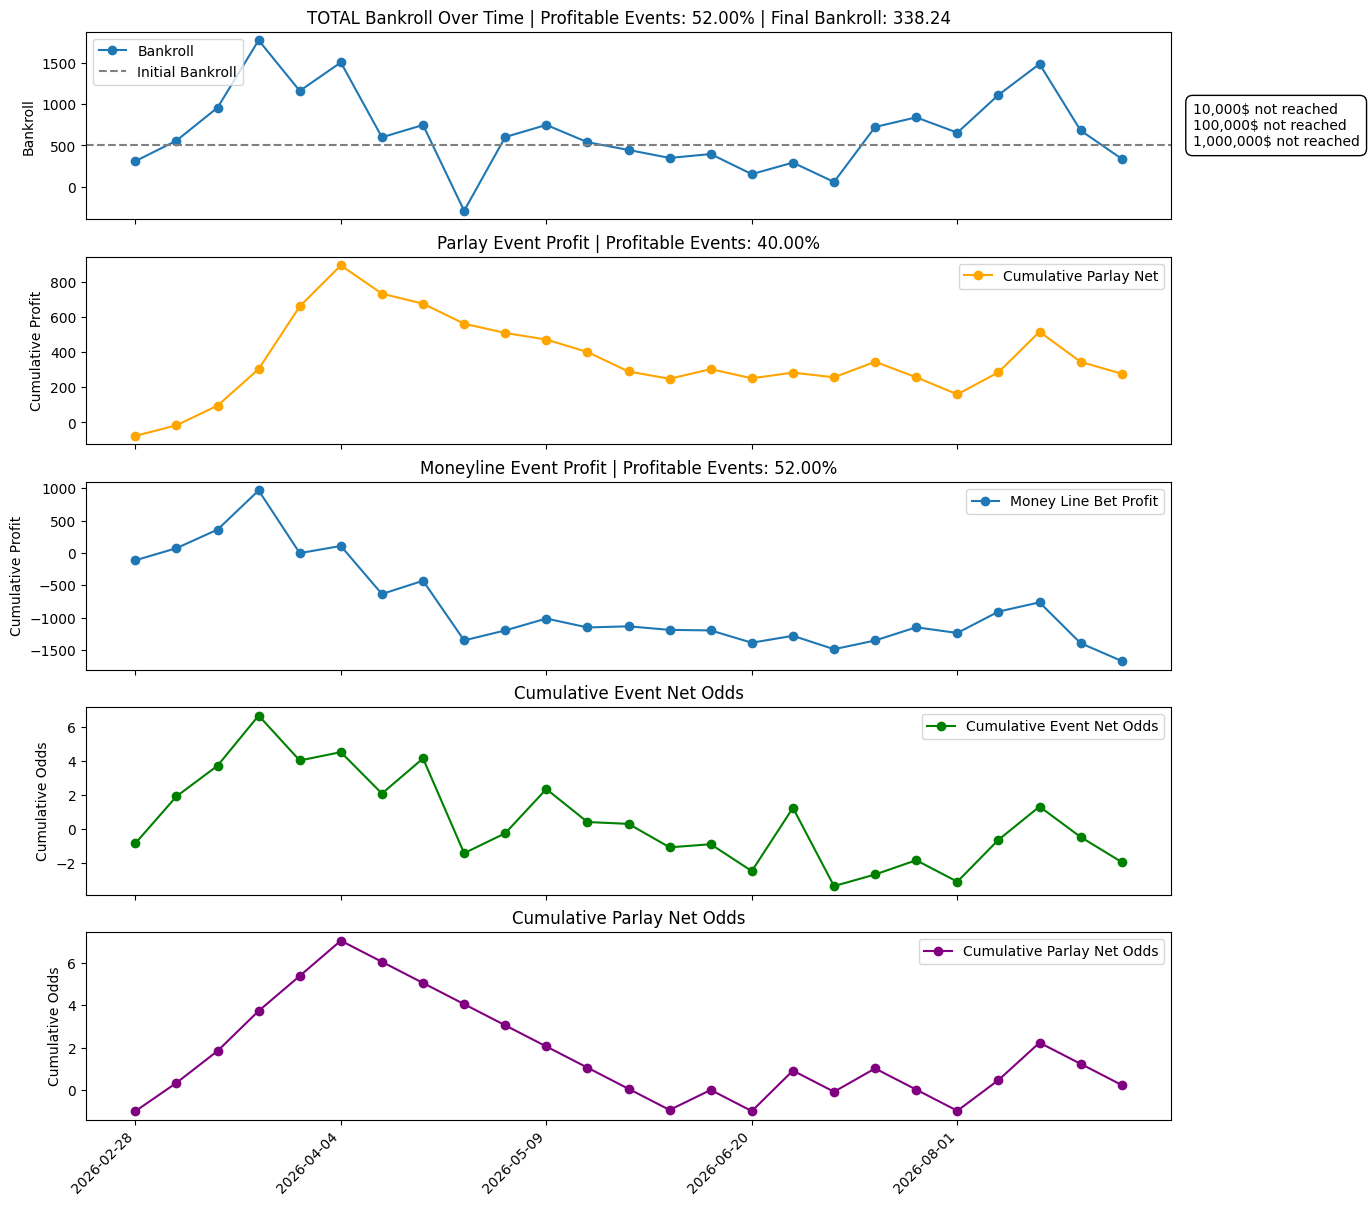

In [4]:
type_ = 'close1'
prob_cols = [f'proba_blue_{type_}_stack', f'proba_red_{type_}_stack']
fair_decimal_odds = [f'dec_fair_{type_}_blue', f'dec_fair_{type_}_red'] 
real_decimal_odds = [f'dec_{type_}_blue', f'dec_{type_}_red']
fight_key = ["date", "fighter_red", "fighter_blue"]

df_test_all = (
    df_test_all
    .drop_duplicates(subset=fight_key)
    .reset_index(drop=True)
)

df_kelly_stack1, df_kelly_stack1_parlay = simulate_kelly(
    df_test_all.dropna(subset=[f'pred_winner_{type_}_stack']).copy(),
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col=f'pred_winner_{type_}_stack',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    N_parlay=250,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)


plot_backtest(df_kelly_stack1, 500, path=None)


Bankroll low on 2026-04-25, replenishing funds


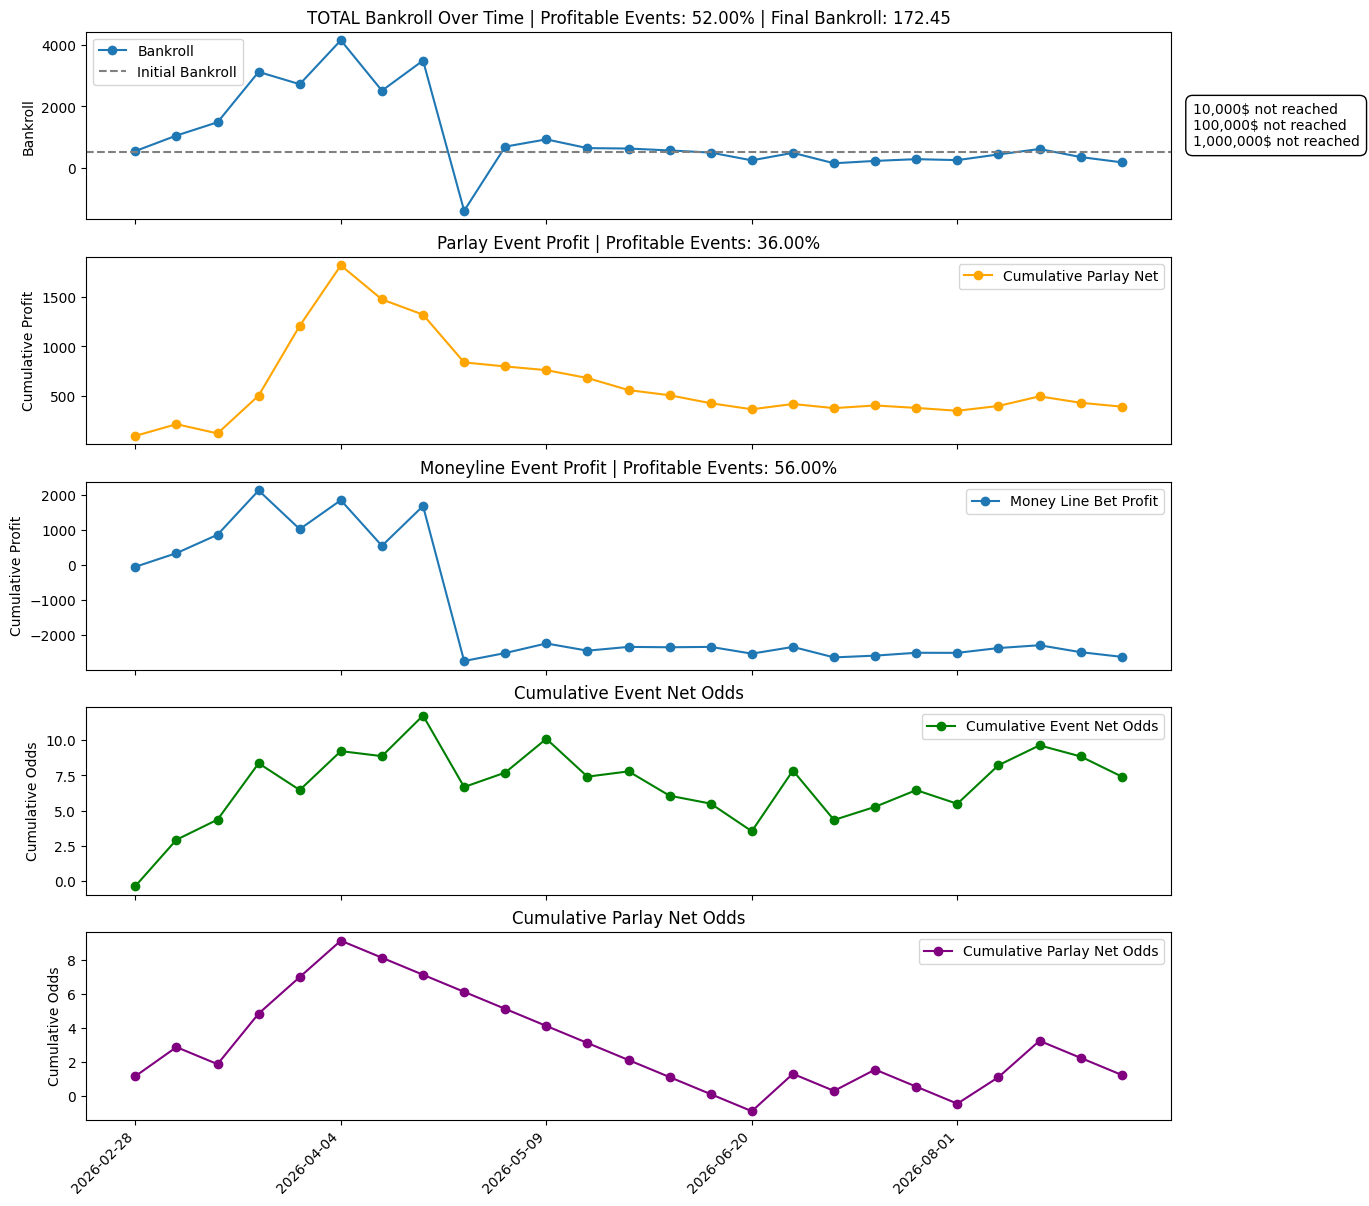

In [5]:
type_ = 'close2'
prob_cols = [f'proba_blue_{type_}_stack', f'proba_red_{type_}_stack']
fair_decimal_odds = [f'dec_fair_{type_}_blue', f'dec_fair_{type_}_red'] 
real_decimal_odds = [f'dec_{type_}_blue', f'dec_{type_}_red']
fight_key = ["date", "fighter_red", "fighter_blue"]

df_test_all = (
    df_test_all
    .drop_duplicates(subset=fight_key)
    .reset_index(drop=True)
)

df_kelly_stack1, df_kelly_stack1_parlay = simulate_kelly(
    df_test_all.dropna(subset=[f'pred_winner_{type_}_stack']).copy(),
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col=f'pred_winner_{type_}_stack',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    N_parlay=250,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)


plot_backtest(df_kelly_stack1, 500, path=None)


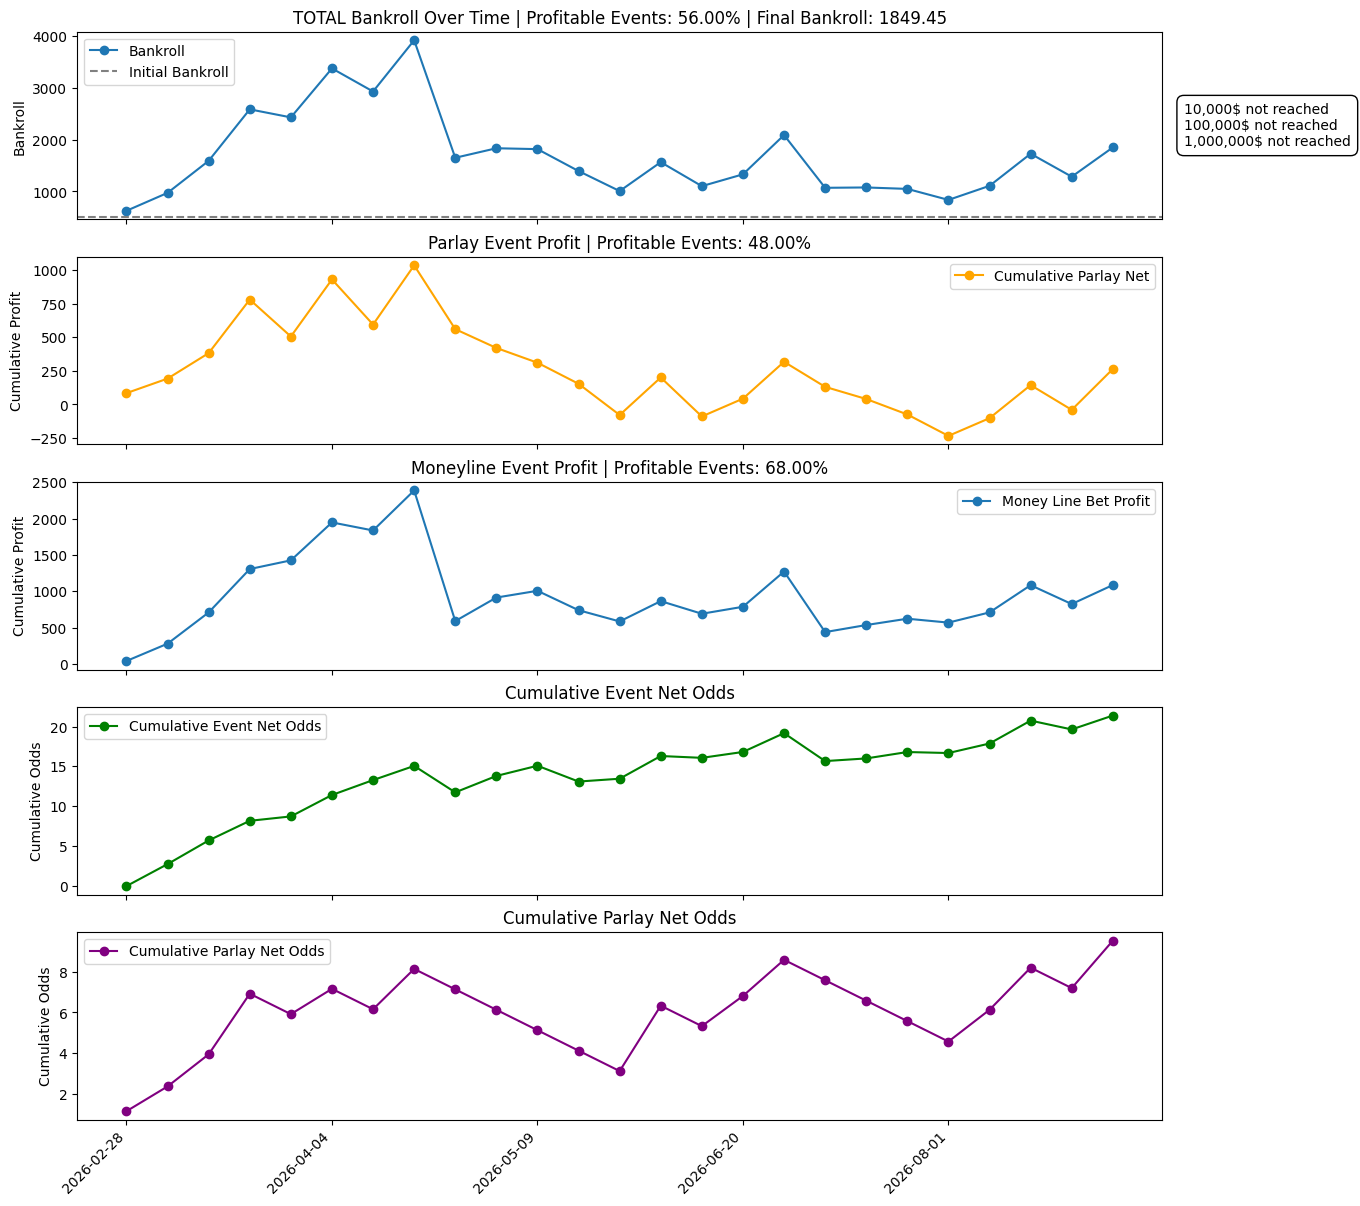

In [6]:
type_ = 'close2'
prob_cols = [f'proba_blue_{type_}', f'proba_red_{type_}']
fair_decimal_odds = [f'dec_fair_{type_}_blue', f'dec_fair_{type_}_red'] 
real_decimal_odds = [f'dec_{type_}_blue', f'dec_{type_}_red']
fight_key = ["date", "fighter_red", "fighter_blue"]

df_test_all = (
    df_test_all
    .drop_duplicates(subset=fight_key)
    .reset_index(drop=True)
)

df_kelly_stack1, df_kelly_stack1_parlay = simulate_kelly(
    df_test_all.dropna(subset=[f'pred_winner_{type_}']).copy(),
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col=f'pred_winner_{type_}',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    N_parlay=250,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)


plot_backtest(df_kelly_stack1, 500, path=None)


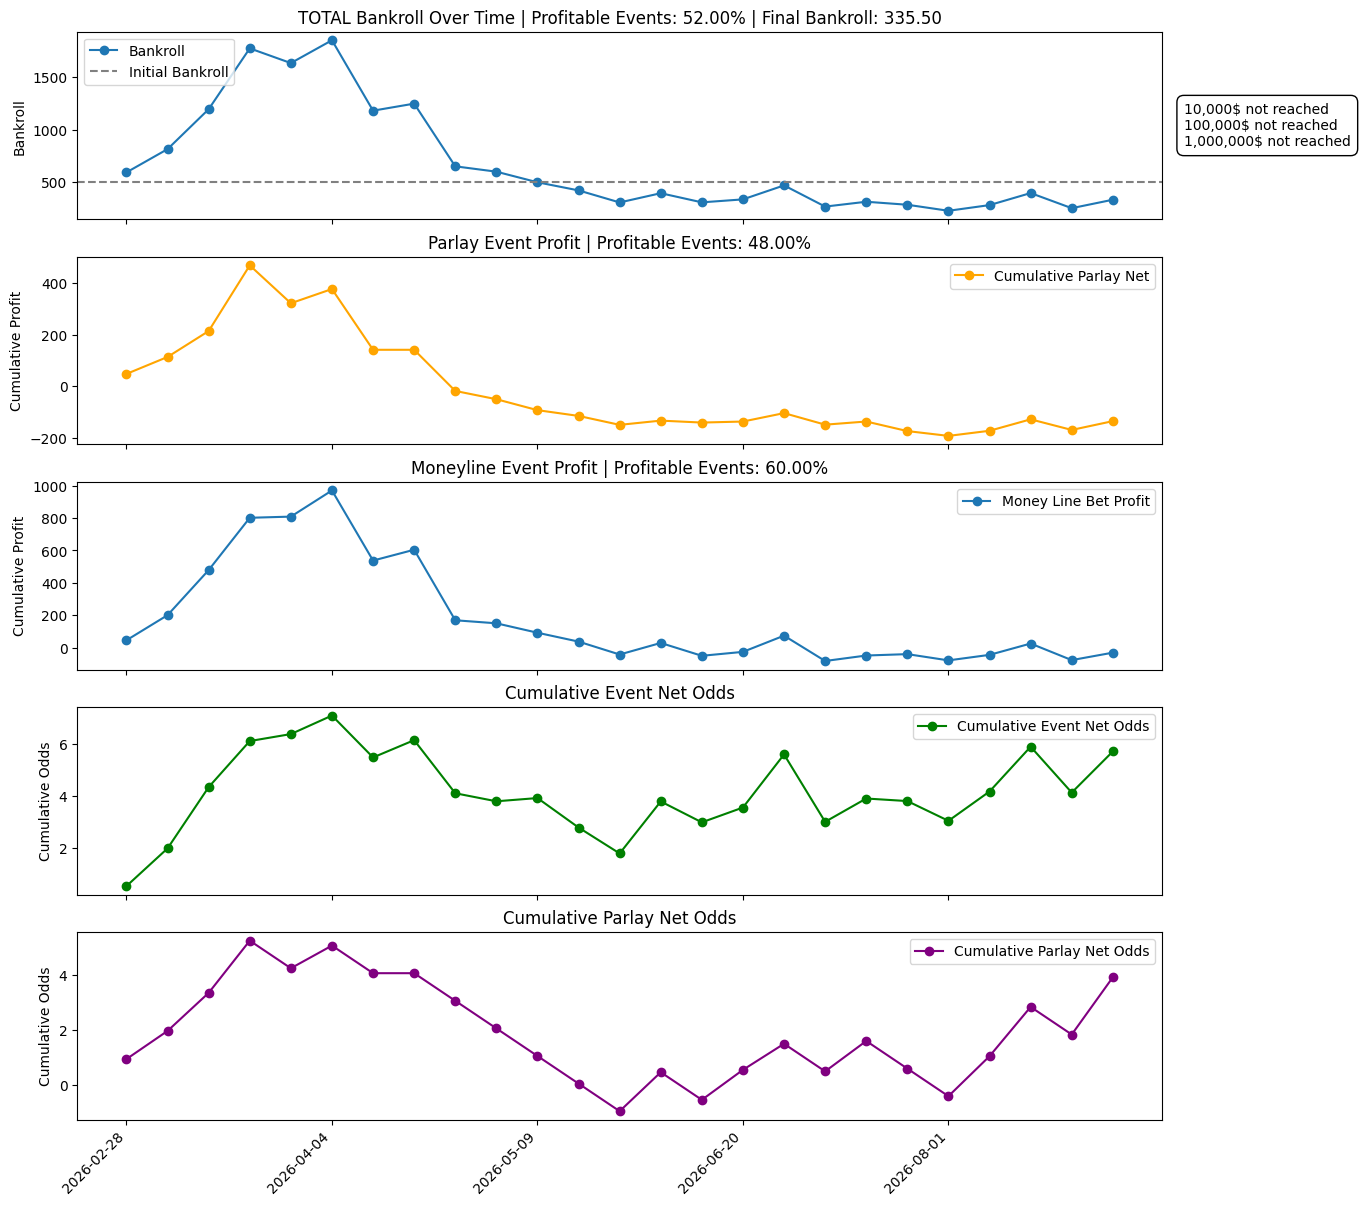

In [7]:
type_ = 'close1'
prob_cols = [f'proba_blue_{type_}', f'proba_red_{type_}']
fair_decimal_odds = [f'dec_fair_{type_}_blue', f'dec_fair_{type_}_red'] 
real_decimal_odds = [f'dec_{type_}_blue', f'dec_{type_}_red']
fight_key = ["date", "fighter_red", "fighter_blue"]

df_test_all = (
    df_test_all
    .drop_duplicates(subset=fight_key)
    .reset_index(drop=True)
)

df_kelly_stack1, df_kelly_stack1_parlay = simulate_kelly(
    df_test_all.dropna(subset=[f'pred_winner_{type_}']).copy(),
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col=f'pred_winner_{type_}',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.4,
    parlay_mdd=.5,
    N=250,
    N_parlay=250,
    calc_parlay=True,
    test_other_ev=False,
    test_bankroll_scaler=False
)


plot_backtest(df_kelly_stack1, 500, path=None)


In [ ]:
df_kelly_stack1.head()

,choice_decimal_odds,f_star_unscaled,choice_proba,choice_fair_odds,choice_ev,choice_real_odds,choice_idx,pred_winner,parlay_net,parlay_net_odds,...,open_blue,real_odds_blue,real_odds_red,sigma_portfolio_scaled,portfolio_fscaled,portfolio_sigma,mu_portfolio,sharpe_portfolio,k,fstar_net
0,1.2,0.133231,0.844190,1.219155,0.013028,1.2,1,1,98.345681,2.151313,...,385.0,4.85,1.2,0.12037,0.080079,0.200265,0.099425,0.496467,0.601052,0.133223
1,1.7751937984496124,0.398549,0.725306,1.840669,0.287558,1.7751937984496124,1,1,98.345681,2.151313,...,109.0,2.09,1.7751937984496124,0.12037,0.239549,0.200265,0.099425,0.496467,0.601052,0.166192
2,1.6666666666666665,0.155573,0.648704,1.712380,0.081173,1.6666666666666665,0,0,98.345681,2.151313,...,-150.0,1.6666666666666665,2.3,0.12037,0.093508,0.200265,0.099425,0.496467,0.601052,0.147645
3,1.4761904761904763,0.000000,0.608451,1.508679,-0.101810,1.4761904761904763,1,1,98.345681,2.151313,...,180.0,2.8,1.4761904761904763,0.12037,0.000000,0.200265,0.099425,0.496467,0.601052,-0.000000
4,1.25,0.005965,0.783651,1.278197,-0.020437,1.25,1,1,98.345681,2.151313,...,300.0,4.0,1.25,0.12037,0.003586,0.200265,0.099425,0.496467,0.601052,0.000000


In [8]:
pct_positive = (
    df_kelly.groupby('date')['parlay_net_odds']
      .first()
      .gt(0)
      .mean()
)

pct_positive

np.float64(0.5)

https://wayback.archive-it.org/5456/20240920160238/https://www.eecs.harvard.edu/cs286r/courses/fall12/papers/Thorpe_KellyCriterion2007.pdf

https://medium.com/raposa-technologies/how-to-use-python-and-the-kelly-criterion-to-optimize-your-stock-portfolio-bb6e43df50c2



In [ ]:
https://web3.arxiv.org/abs/2207.14124?utm_source=chatgpt.com

https://pubmed.ncbi.nlm.nih.gov/35205582/

https://summit.sfu.ca/item/34958?utm_source=chatgpt.com


https://www.glicko.net/glicko/glicko2.pdf

https://www.glicko.net/glicko.html

https://ojs.aaai.org/index.php/AIIDE/article/view/5233


https://arxiv.org/abs/2303.16741?utm_source=chatgpt.com

https://opisthokonta.net/?cat=48


https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling-dixon-coles-and-time-weighting/

